In [1]:
import os

dataset_path = "../dataset/CCIH"

for folder in ["train","valid","test"]:
    path = os.path.join(dataset_path, folder)

    print(folder)

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)

        print(cls, len(os.listdir(cls_path)))

    print("----------------")

train
Acc 270
Nat 270
----------------
valid
Acc 61
Nat 61
----------------
test
Acc 94
Nat 94
----------------


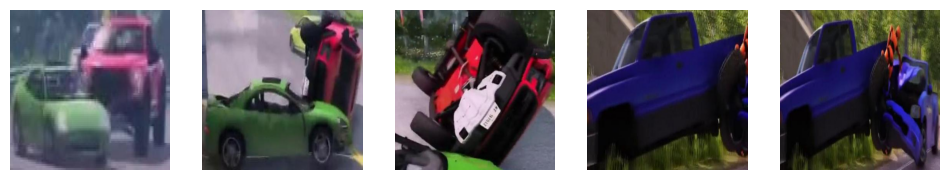

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os


img_path = "../Dataset/CCIH/train/Acc"

images = os.listdir(img_path)[:5]


plt.figure(figsize=(12,6))

for i,img in enumerate(images):

    image = Image.open(
        os.path.join(img_path,img)
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
train_data = train_datagen.flow_from_directory(
    "../Dataset/CCIH/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)


valid_data = valid_datagen.flow_from_directory(
    "../Dataset/CCIH/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

Found 540 images belonging to 2 classes.
Found 122 images belonging to 2 classes.


In [5]:
train_data.class_indices

{'Acc': 0, 'Nat': 1}

import libary

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


Dataset path

In [7]:
train_dir = "../Dataset/CCIH/train"
valid_dir = "../Dataset/CCIH/valid"
test_dir = "../Dataset/CCIH/test"

Image preparation

In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../Dataset/CCIH/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "../Dataset/CCIH/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../Dataset/CCIH/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 540 files belonging to 2 classes.
Found 122 files belonging to 2 classes.
Found 188 files belonging to 2 classes.


In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1)
])

In [11]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [12]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Lambda(preprocess_input),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.build((None, 224, 224, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 397ms/step - accuracy: 0.5944 - loss: 0.7564 - val_accuracy: 0.7213 - val_loss: 0.5675
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 335ms/step - accuracy: 0.7185 - loss: 0.5603 - val_accuracy: 0.7705 - val_loss: 0.4815
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 325ms/step - accuracy: 0.7907 - loss: 0.4520 - val_accuracy: 0.7951 - val_loss: 0.4379
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - accuracy: 0.8148 - loss: 0.4150 - val_accuracy: 0.8279 - val_loss: 0.3894
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.8556 - loss: 0.3338 - val_accuracy: 0.8279 - val_loss: 0.3715
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 334ms/step - accuracy: 0.9056 - loss: 0.2788 - val_accuracy: 0.8361 - val_loss: 0.3581
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.9259 - loss: 0.2414 - val_accuracy: 0.8279 - val_loss: 0.3481
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.9222 - loss: 0.2363 - val_accuracy: 0

In [16]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step - accuracy: 0.8191 - loss: 0.3607
Test Loss: 0.3606970012187958
Test Accuracy: 0.8191489577293396


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.class_names
))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

         Acc       0.87      0.76      0.81        94
         Nat       0.78      0.88      0.83        94

    accuracy                           0.82       188
   macro avg       0.82      0.82      0.82       188
weighted avg       0.82      0.82      0.82       188

Confusion Matrix:
[[71 23]
 [11 83]]


In [18]:
model.save("../models/vision/traffic_incident_model.keras")